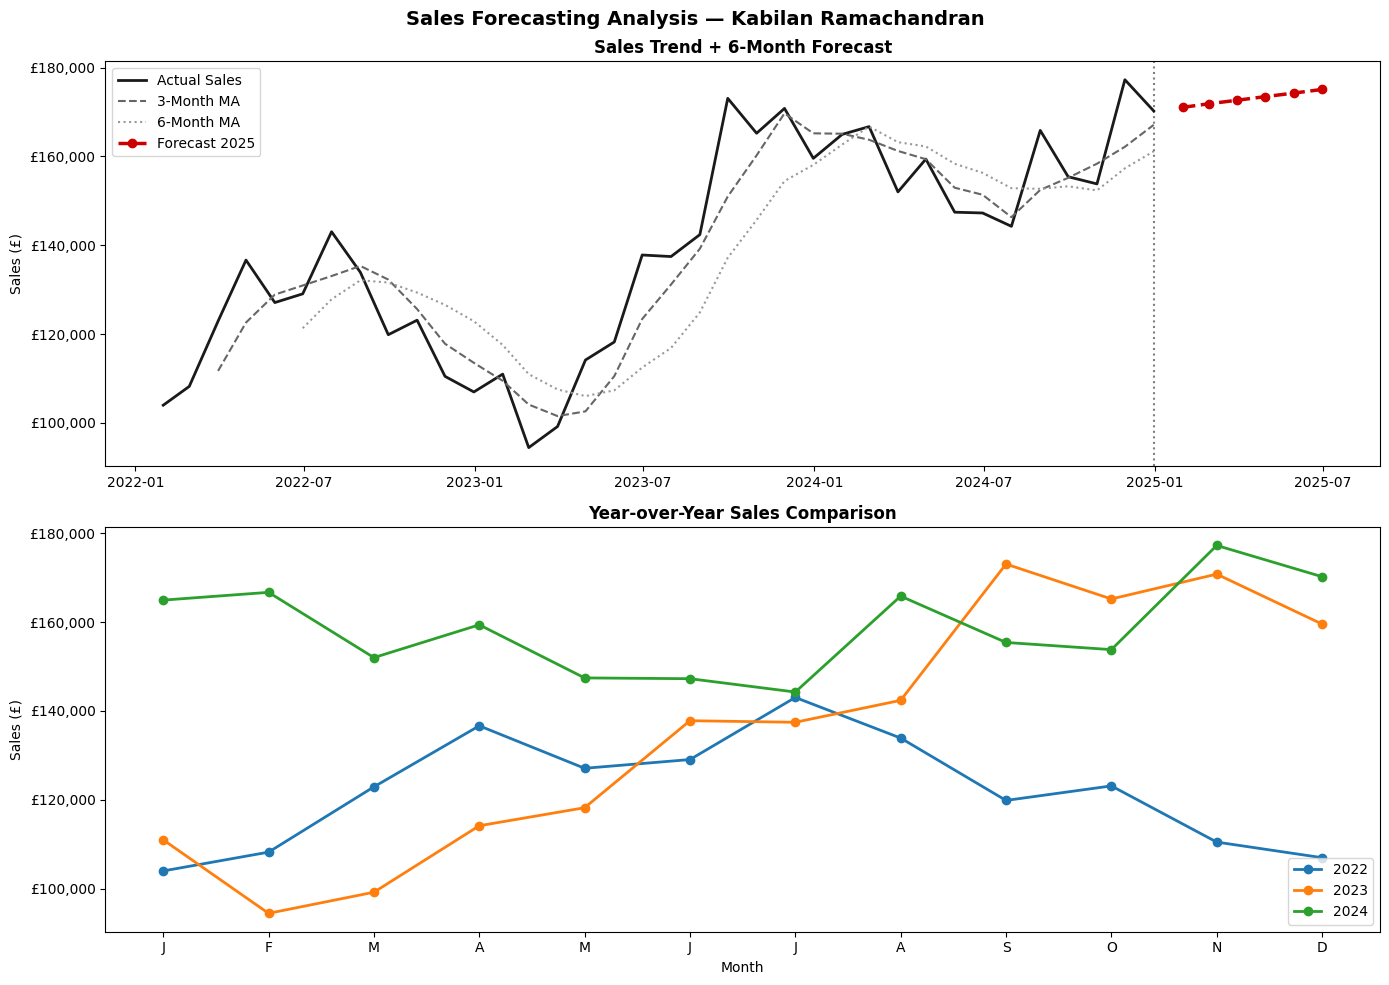

SALES FORECASTING INSIGHTS
2022 Avg Monthly Sales: £122,102
2023 Avg Monthly Sales: £135,270
2024 Avg Monthly Sales: £158,719
2025 Forecast (Jan):    £171,040
2025 Forecast (Jun):    £175,078
Projected Growth:       2.4%
✅ Forecasting Complete!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# Historical data
months = pd.date_range('2022-01-01', '2024-12-31', freq='ME')
n = len(months)
trend = np.linspace(100000, 180000, n)
seasonal = 20000 * np.sin(np.linspace(0, 4*np.pi, n))
noise = np.random.normal(0, 8000, n)
sales = trend + seasonal + noise

df = pd.DataFrame({'Date': months, 'Sales': sales.round(0)})

# Simple forecasting using moving average + trend
window = 3
df['MA3'] = df['Sales'].rolling(window).mean()
df['MA6'] = df['Sales'].rolling(6).mean()

# Forecast next 6 months
last_trend = (df['Sales'].iloc[-6:].mean() - df['Sales'].iloc[-12:-6].mean()) / 6
forecast_dates = pd.date_range('2025-01-31', periods=6, freq='ME')
last_value = df['Sales'].iloc[-1]
forecast_values = [last_value + (last_trend * (i+1)) for i in range(6)]
forecast_df = pd.DataFrame({'Date': forecast_dates, 'Forecast': forecast_values})

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Sales Forecasting Analysis — Kabilan Ramachandran', fontsize=14, fontweight='bold')

# Chart 1: Historical + Forecast
axes[0].plot(df['Date'], df['Sales'], color='#1A1A1A', linewidth=2, label='Actual Sales')
axes[0].plot(df['Date'], df['MA3'], color='#666666', linewidth=1.5, linestyle='--', label='3-Month MA')
axes[0].plot(df['Date'], df['MA6'], color='#999999', linewidth=1.5, linestyle=':', label='6-Month MA')
axes[0].plot(forecast_df['Date'], forecast_df['Forecast'], color='#CC0000', linewidth=2.5,
             linestyle='--', marker='o', markersize=6, label='Forecast 2025')
axes[0].axvline(x=df['Date'].iloc[-1], color='black', linestyle=':', alpha=0.5)
axes[0].set_title('Sales Trend + 6-Month Forecast', fontweight='bold')
axes[0].set_ylabel('Sales (£)')
axes[0].legend()
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'£{x:,.0f}'))

# Chart 2: YoY comparison
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
pivot = df.pivot_table(values='Sales', index='Month', columns='Year')
for year in pivot.columns:
    axes[1].plot(pivot.index, pivot[year], marker='o', linewidth=2, label=str(year))
axes[1].set_title('Year-over-Year Sales Comparison', fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Sales (£)')
axes[1].legend()
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'£{x:,.0f}'))
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])

plt.tight_layout()
plt.savefig('sales_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

print("="*50)
print("SALES FORECASTING INSIGHTS")
print("="*50)
print(f"2022 Avg Monthly Sales: £{df[df['Year']==2022]['Sales'].mean():,.0f}")
print(f"2023 Avg Monthly Sales: £{df[df['Year']==2023]['Sales'].mean():,.0f}")
print(f"2024 Avg Monthly Sales: £{df[df['Year']==2024]['Sales'].mean():,.0f}")
print(f"2025 Forecast (Jan):    £{forecast_values[0]:,.0f}")
print(f"2025 Forecast (Jun):    £{forecast_values[5]:,.0f}")
print(f"Projected Growth:       {((forecast_values[5]-forecast_values[0])/forecast_values[0]*100):.1f}%")
print("✅ Forecasting Complete!")